# Plotting concept gradient importances

This notebook shows the results of performing Concept Whitening (CW) on a Graph Neural Network (GNN) trained to classify document graphs obtained from the 10 newsgroups dataset. The GNN does not use residual connections and has 3 graph convolutional layers, with the convolutional layers being PyTorch Geometric's conv.GCNConv. Note that in our case, we apply the CW module to the output of our third graph convolutional layer.

The 10 newsgroups dataset has the following 10 document classes: 'business', 'entertainment', 'food', 'graphics', 'historical', 'medical', 'politics', 'space', 'sport' and 'technology'. Accordingly, for CW there are 10 different graph concepts, with each graph concept corresponding to an individual class, i.e., the 'business' graph concept for the 'business' document class, the 'entertainment' graph concept for the 'entertainment' class, etc.

There are 4 different types of graph concepts:

1. Frequent subgraphs: Subgraphs mined from the training document graphs of each class, that exceed a support threshold within the same document class.
   
2. Graph pattern concept intents: Sets of maximal common subgraphs mined from the training document graphs of each class, that satisfy the definition of being graph pattern concept intents.

3. Closed subgraphs: Individual subgraphs belonging to the intents of the graph pattern concepts described above.

4. Frequent equivalence classes: Sets of frequent subgraphs whose supports consist of identical training document graphs.

CW can be performed using any number and combination of concepts. Here, CW was performed using the following five graph concepts simultaneously: 'business', 'entertainment', 'food', 'graphics' and 'historical'.

Concept gradient importance measures the importance of a concept for the classification of a test object, as belonging to a particular class, e.g., the importance of the 'business' graph concept for classifying a test document graph as belonging to the 'business' class. Concept gradient importances range from 0 to 1, with higher values denoting greater importance. 

The chemical molecular graphs CW paper simply states that concept gradient importance measures the contribution of each concept, by computing the sum of the positive directional derivatives of the gradients, along the specific axis in the latent space of the CW layer, representing that concept. We can derive the formal equation for concept gradient importance by referring to the equation for the extremely similar TCAV score.

In the case of TCAV, suppose that we are considering the case of a Deep Learning (DL) model trained to classify images as belonging to $K$ classes. Consequently, such a DL model's final output layer would have $K$ output neurons, with each neuron outputting the logit value of an individual class $k$, before applying the softmax function to obtain the output probabilities for each class $k$. The function $h_k$ denotes the logit value for class $k$.

The gradient of the logit value for class $k$, with respect to individual input features such as the pixel at position $(a,b)$ of input $x$, constitutes a saliency map as defined below.

\begin{equation} 
    \frac{\partial h_{k}(x)}{\partial x_{a,b}}
\end{equation}

The saliency map measures the sensitivity of the output prediction of class $k$, to changes in the magnitude of pixel $(a,b)$. However, TCAV does not measure the sensitivity of the output prediction of a specific class, with respect to individual input features like the pixels of the input $x$. Instead, it aims to measure the sensitivity of the output prediction of the class, with respect to a concept $C$, in the neural activations of layer $l$ of the DL model. Stated differently, TCAV is designed to measure the sensitivity of the predictions of the DL model, to changes in its inputs towards the direction of a concept, at the neural activations of layer $l$.

The neural activations of layer $l$ for an input $x$ can be denoted using the function $f_{l}(x)$. The direction of the concept $C$ in the layer $l$ is provided using a unit Concept Activation Vector (CAV) $v^{l}_{C}$. Thus, the "conceptual sensitivity" of class $k$ to concept $C$ in the layer $l$ can be computed using the directional derivative $S_{C,k,l}(x)$, stated below.

\begin{equation} 
S_{C,k,l}(x) = \nabla h_{l,k}(f_{l}(x)) \cdot v^{l}_{C}
\end{equation}

The TCAV score uses the directional derivative from the above equation to compute the conceptual sensitivity of a DL model across entire classes of inputs. Supposing that $k$ is a class label for a given supervised learning task, and let $X_{k}$ denote the set of all inputs belonging to class $k$, then the TCAV score is defined as follows.

\begin{equation} 
\text{TCAV}_{\text{{Q}}_{C,k,l}} = \frac{\mathopen| \{ x \in X_{k}: S_{C,k,l}(x) > 0\}\mathclose|}{\mathclose|X_{k}\mathclose|}
\end{equation}

The TCAV score calculates the fraction of inputs belonging to class $k$, whose activation vector in layer $l$ was positively influenced by the concept $C$. Thus, $\text{TCAV}_{\text{{Q}}_{C,k,l}} \in [0,1]$.

While similar to the use of CAVs, Concept Whitening (CW) does not assign a single concept $C$ to a layer $l$ of a DL model. Instead, given a set of $m$ concepts $c_{1}, c_{2}, ..., c_{m}$, their respective concept vectors are each aligned, with an individual axis of the latent space representation of layer $l$, i.e., the axis representing the $j$th dimension $l_{j}$ of $l$, is aligned with concept $c_{j}$, for any class $k$. Consequently, the equation for $S_{C,k,l}(x)$ is reformulated for the use of CW as defined below.

\begin{equation}
S_{c_{j},k,l}(x) = \nabla h_{l_{j},k}(f_{l}(x))
\end{equation}

Instead of considering the directional derivative across the entire layer $l$, only the $j$th dimension $l_{j}$ that is assigned to the concept $c_{j}$ is considered. Since CW ultimately aims to align each concept vector with a latent space axis, perfect CW alignment is achieved when a concept vector and the vector representing its assigned latent axis are superimposed, i.e., they are the same. Thus, unlike the equation for $S_{C,k,l}(x)$, the equation for $S_{c_{j},k,l}(x)$ does not need a unit CAV $v^{l}_{C}$ to calculate the directional derivative. Instead, it uses the vector representing the latent space axis for the concept $c_{j}$ in order to calculate the directional derivative.

Based on the equations for $\text{TCAV}_{\text{{Q}}_{C,k,l}}$ and $S_{C,k,l}(x)$, the concept gradient importance $CI_{c_{j},k,l}$ can then be defined as follows.

\begin{equation} 
CI_{c_{j},k,l} = \frac{\mathopen| \{ x \in X_{k}: S_{c_{j},k,l}(x) > 0\}\mathclose|}{\mathclose|X_{k}\mathclose|}
\end{equation}

Similar to the equation for $\text{TCAV}_{\text{{Q}}_{C,k,l}}$, $CI_{c_{j},k,l}$ also computes the fraction of inputs belonging to class $k$ that were positively influenced by the concept $c_{j}$. However, unlike $\text{TCAV}_{\text{{Q}}_{C,k,l}}$ which assigns all of the latent space of layer $l$ to a single concept $C$, $CI_{c_{j},k,l}$ instead only assigns the axis corresponding to the $j$th dimension $l_{j}$ to the concept $c_{j}$. Thus, unlike TCAV, CW can assign multiple concepts to the layer $l$. Like $\text{TCAV}_{\text{{Q}}_{C,k,l}}$, $CI_{c_{j},k,l} \in [0,1]$.

$CI_{c_{j},k,l}$ is the formula used to compute the values of the bar plots.

## Concept gradient importances for the 'cricket' document class

GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)


/home/eric/Eric/PhD/ResearchCode/stable-AMR-graphs-concept-whitening-revised/iterative_normalization_2.py:41: UserWarning: This overload of baddbmm is deprecated:
	baddbmm(Number beta, Tensor input, Number alpha, Tensor batch1, Tensor batch2, *, Tensor out = None)
Consider using one of the following signatures instead:
	baddbmm(Tensor input, Tensor batch1, Tensor batch2, *, Number beta = 1, Number alpha = 1, Tensor out = None) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1661.)
  Sigma = torch.baddbmm(eps, P[0], 1. / m, xc, xc.transpose(1, 2))
/home/eric/anaconda3/envs/general-testbed/lib/python3.12/site-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result

GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)
GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)
GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)


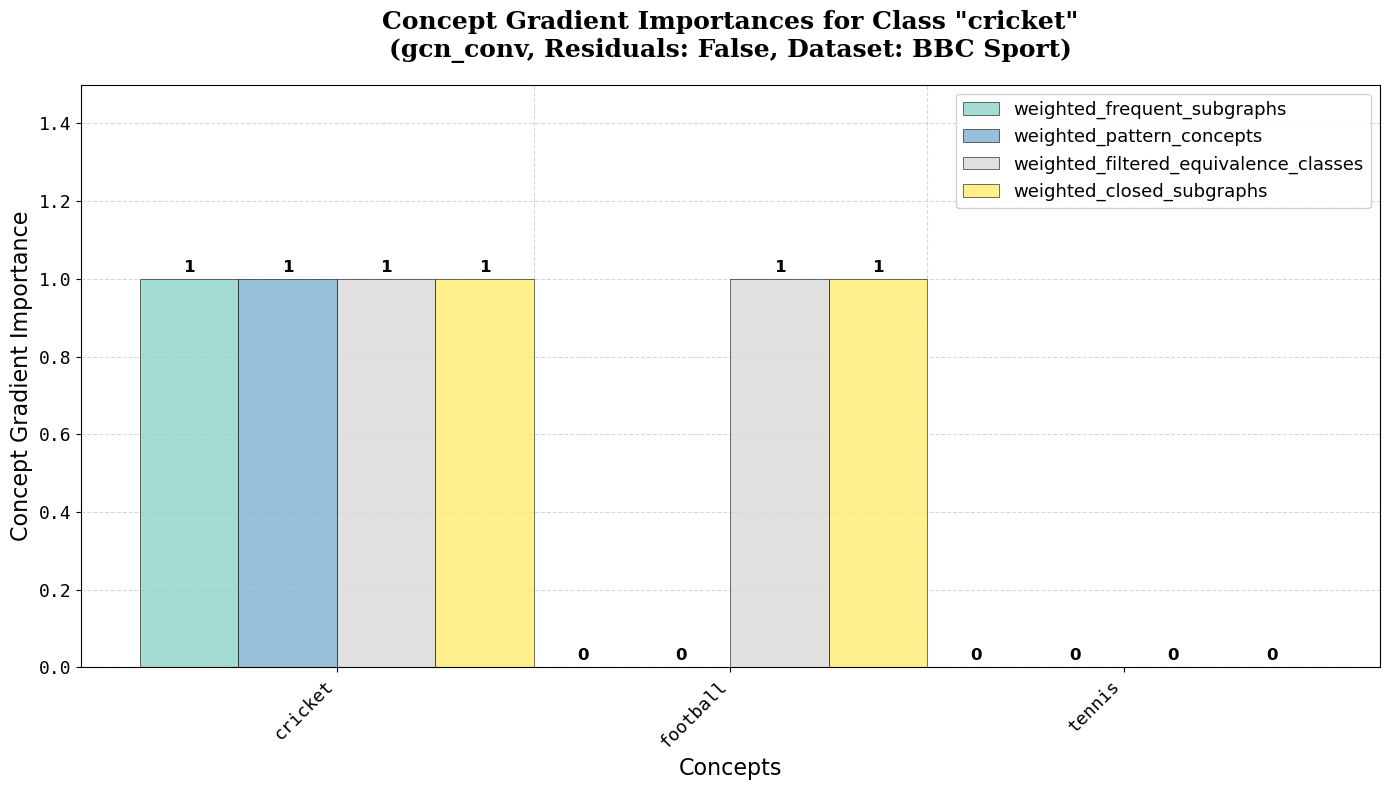

In [1]:
%run 'main.py' --dataset bbcsport --operation evaluation --mode concept_gradient_importance

## Concept gradient importances for the 'football' document class

GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)


/home/eric/Eric/PhD/ResearchCode/stable-AMR-graphs-concept-whitening-revised/iterative_normalization_2.py:41: UserWarning: This overload of baddbmm is deprecated:
	baddbmm(Number beta, Tensor input, Number alpha, Tensor batch1, Tensor batch2, *, Tensor out = None)
Consider using one of the following signatures instead:
	baddbmm(Tensor input, Tensor batch1, Tensor batch2, *, Number beta = 1, Number alpha = 1, Tensor out = None) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1661.)
  Sigma = torch.baddbmm(eps, P[0], 1. / m, xc, xc.transpose(1, 2))
/home/eric/anaconda3/envs/general-testbed/lib/python3.12/site-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result

GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)
GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)
GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)


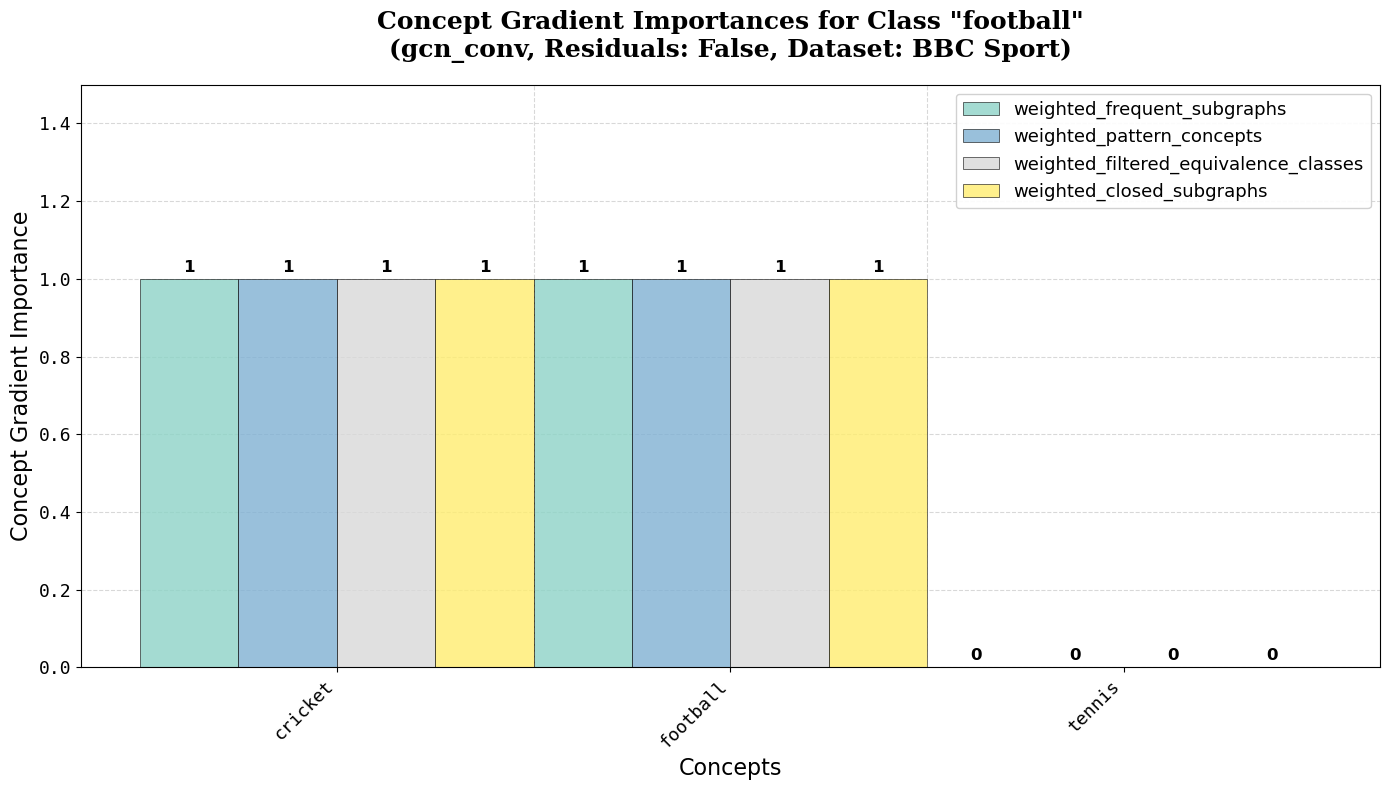

In [1]:
%run 'main.py' --dataset bbcsport --operation evaluation --mode concept_gradient_importance

## Concept gradient importances for the 'tennis' document class

GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)


/home/eric/Eric/PhD/ResearchCode/stable-AMR-graphs-concept-whitening-revised/iterative_normalization_2.py:41: UserWarning: This overload of baddbmm is deprecated:
	baddbmm(Number beta, Tensor input, Number alpha, Tensor batch1, Tensor batch2, *, Tensor out = None)
Consider using one of the following signatures instead:
	baddbmm(Tensor input, Tensor batch1, Tensor batch2, *, Number beta = 1, Number alpha = 1, Tensor out = None) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1661.)
  Sigma = torch.baddbmm(eps, P[0], 1. / m, xc, xc.transpose(1, 2))
/home/eric/anaconda3/envs/general-testbed/lib/python3.12/site-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result

GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)
GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)
GNN(
  (lin_1): Linear(in_features=300, out_features=5, bias=True)
  (norm1): IterNormRotation(300, num_channels=300, T=5, eps=1e-05, momentum=0.1, affine=False)
  (conv1): GCNConv(300, 300)
  (conv2): GCNConv(300, 300)
)


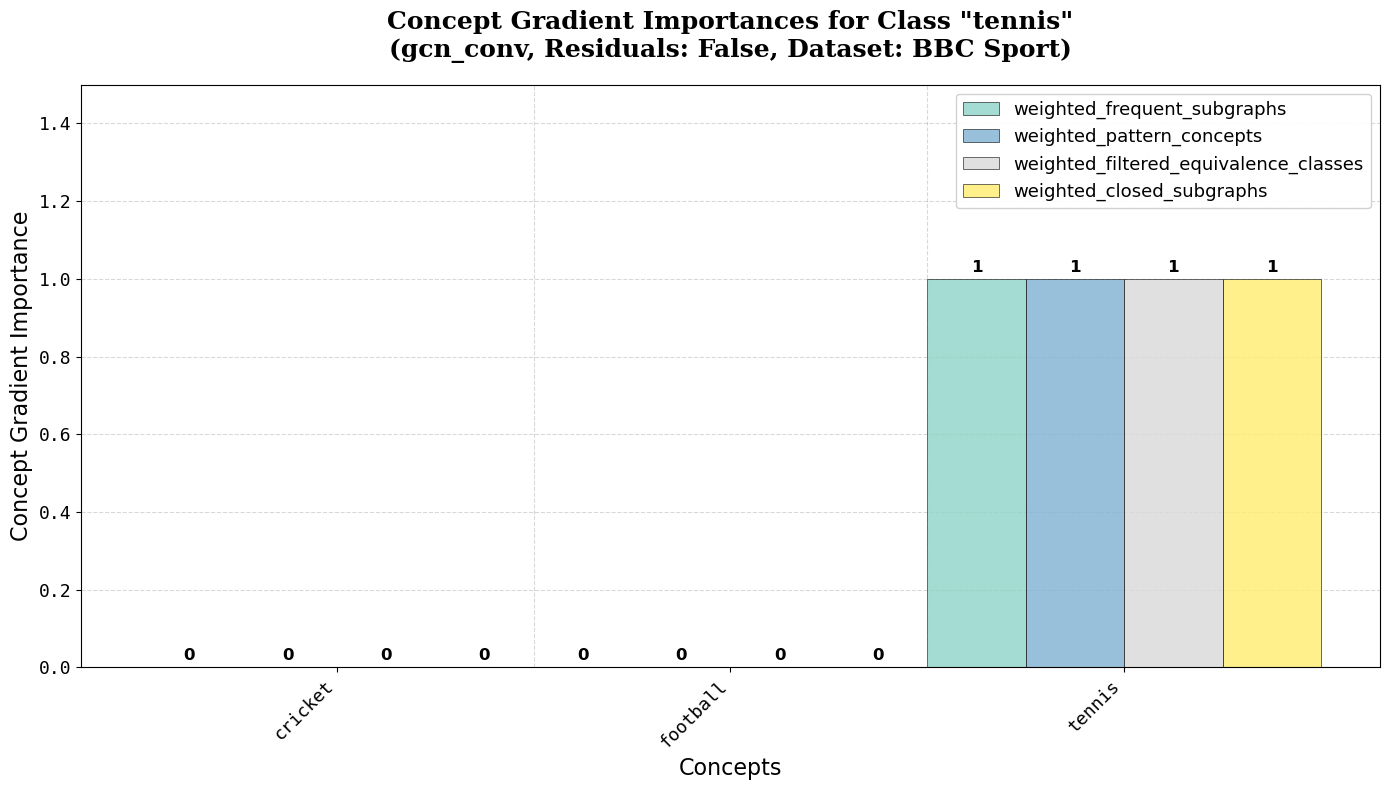

In [1]:
%run 'main.py' --dataset bbcsport --operation evaluation --mode concept_gradient_importance